# Importing modules and settings

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
from matplotlib.pyplot import rc_context

General settings of Scanpy

In [3]:
sc.settings.verbosity = 3 
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\umap\distances.py:

scanpy==1.9.3 anndata==0.9.1 umap==0.5.3 numpy==1.24.4 scipy==1.11.1 pandas==2.0.3 scikit-learn==1.3.0 statsmodels==0.14.0 pynndescent==0.5.10


C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\umap\umap_.py:660: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()


In [4]:
results_file = './Serotonergic_data_labels_transferred.h5ad'

# Label transfering with Ingest

Reading S.med reference dataset with cluster annotation:

In [5]:
adata_ref = sc.read_h5ad('./reference.h5ad')

In [6]:
adata_ref

AnnData object with n_obs × n_vars = 28738 × 24000
    obs: 'Size', 'Library', 'Sample', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_3_names', 'broad_names'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_3_colors', 'leiden_3_names_colors', 'leiden_4_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups_logreg_leiden_1', 'rank_genes_groups_logreg_leiden_2', 'rank_genes_groups_logreg_le

In [7]:
adata_ref.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000001,h1SMcG0000001,Gene Expression,h1SMcT0000001.1,other,-,-,dd_Smed_v6_17026_0_4,SMEST050392001.1,SMESG000050392.1,"dd_Smed_v6_17026_0_4,dd_Smed_v6_17026_0_5",...,68,0.002499,99.764012,72.0,True,0.002016,0.187538,0.499244,0.001365,0.031118
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,MSTRG.9914,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",MSTRG.9914,dd_Smed_v6_5323_0_1,...,173,0.006108,99.399618,176.0,True,0.005309,0.118957,0.310118,0.003640,0.050272
h1SMcG0000010,h1SMcG0000010,Gene Expression,h1SMcT0000010.1,other,-,-,-,-,-,-,...,9,0.000312,99.968766,9.0,True,0.000254,0.123262,0.321988,0.000173,0.011020
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,MSTRG.9916,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...",MSTRG.9916,dd_Smed_v6_6416_0_1,...,1705,0.063092,94.082943,1818.0,True,0.053033,0.159237,0.421197,0.036676,0.158263
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,MSTRG.9913,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",MSTRG.9913,dd_Smed_v6_20296_0_1,...,22,0.000798,99.923651,23.0,True,0.000683,0.161131,0.426421,0.000461,0.018268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0035270,h1SMnG0035270,Gene Expression,h1SMnT0035270.1,hconf,-,-,-,-,-,-,...,1,0.000035,99.996530,1.0,True,0.000042,0.191891,0.511248,0.000028,0.004682
h1SMnG0035333,h1SMnG0035333,Gene Expression,h1SMnT0035333.1,other,-,-,-,-,-,-,...,1,0.000035,99.996530,1.0,True,0.000047,0.309073,0.834401,0.000030,0.005071
h1SMnG0035418,h1SMnG0035418,Gene Expression,h1SMnT0035418.1,other,-,-,-,-,-,-,...,2,0.000069,99.993059,2.0,True,0.000071,0.090285,0.231048,0.000048,0.005916
h1SMnG0035546,h1SMnG0035546,Gene Expression,h1SMnT0035546.1,other,-,-,-,-,-,-,...,1,0.000035,99.996530,1.0,True,0.000044,0.226124,0.605653,0.000028,0.004793


In [8]:
adata_ref.obs

,Size,Library,Sample,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,leiden_3_names,broad_names
L23_1_CATCAAGTGAACAGGCGTCTGTCA,L,L1,L_L1,295.0,255,255,295.0,0.0,0.0,2,7,8,9,pgrn+ parenchymal cells 2,parenchymal
L23_1_AACGCTTAACACAGAAAAGACGGA,L,L1,L_L1,125.0,117,117,125.0,0.0,0.0,10,17,16,19,protonephridia proximal tubule cells,protonephridia
L23_1_AGTCACTAGAACAGGCCGGATTGC,M,L1,M_L1,480.0,348,348,480.0,0.0,0.0,1,0,1,0,neoblasts 1,neoblasts
L23_1_CCGTGAGAGCTAACGACGCATACA,M,L1,M_L1,668.0,510,510,668.0,0.0,0.0,3,27,26,26,muscle progenitors,muscle
L23_1_CGACTGGAATAGCGACTATCAGCA,M,L1,M_L1,267.0,240,240,267.0,0.0,0.0,3,15,18,65,secretory 1,secretory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L23_2_CCGAAGTACCTCTATCAACGCTTA,M,L2,M_L2,706.0,576,576,706.0,0.0,0.0,12,42,43,47,pkd-1+ neurons,neurons
L23_2_CGAACTTAACCTCCAACCGTGAGA,M,L2,M_L2,724.0,508,508,724.0,0.0,0.0,1,0,1,0,neoblasts 1,neoblasts
L23_2_ACAGCAGATCTTCACAAGATGTAC,L,L2,L_L2,174.0,153,153,174.0,0.0,0.0,21,28,30,32,protonephridia flame cells,protonephridia
L23_2_AAACATCGATGCCTAACATACCAA,L,L2,L_L2,336.0,275,275,336.0,0.0,0.0,8,19,19,43,epidermis,epidermal


C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


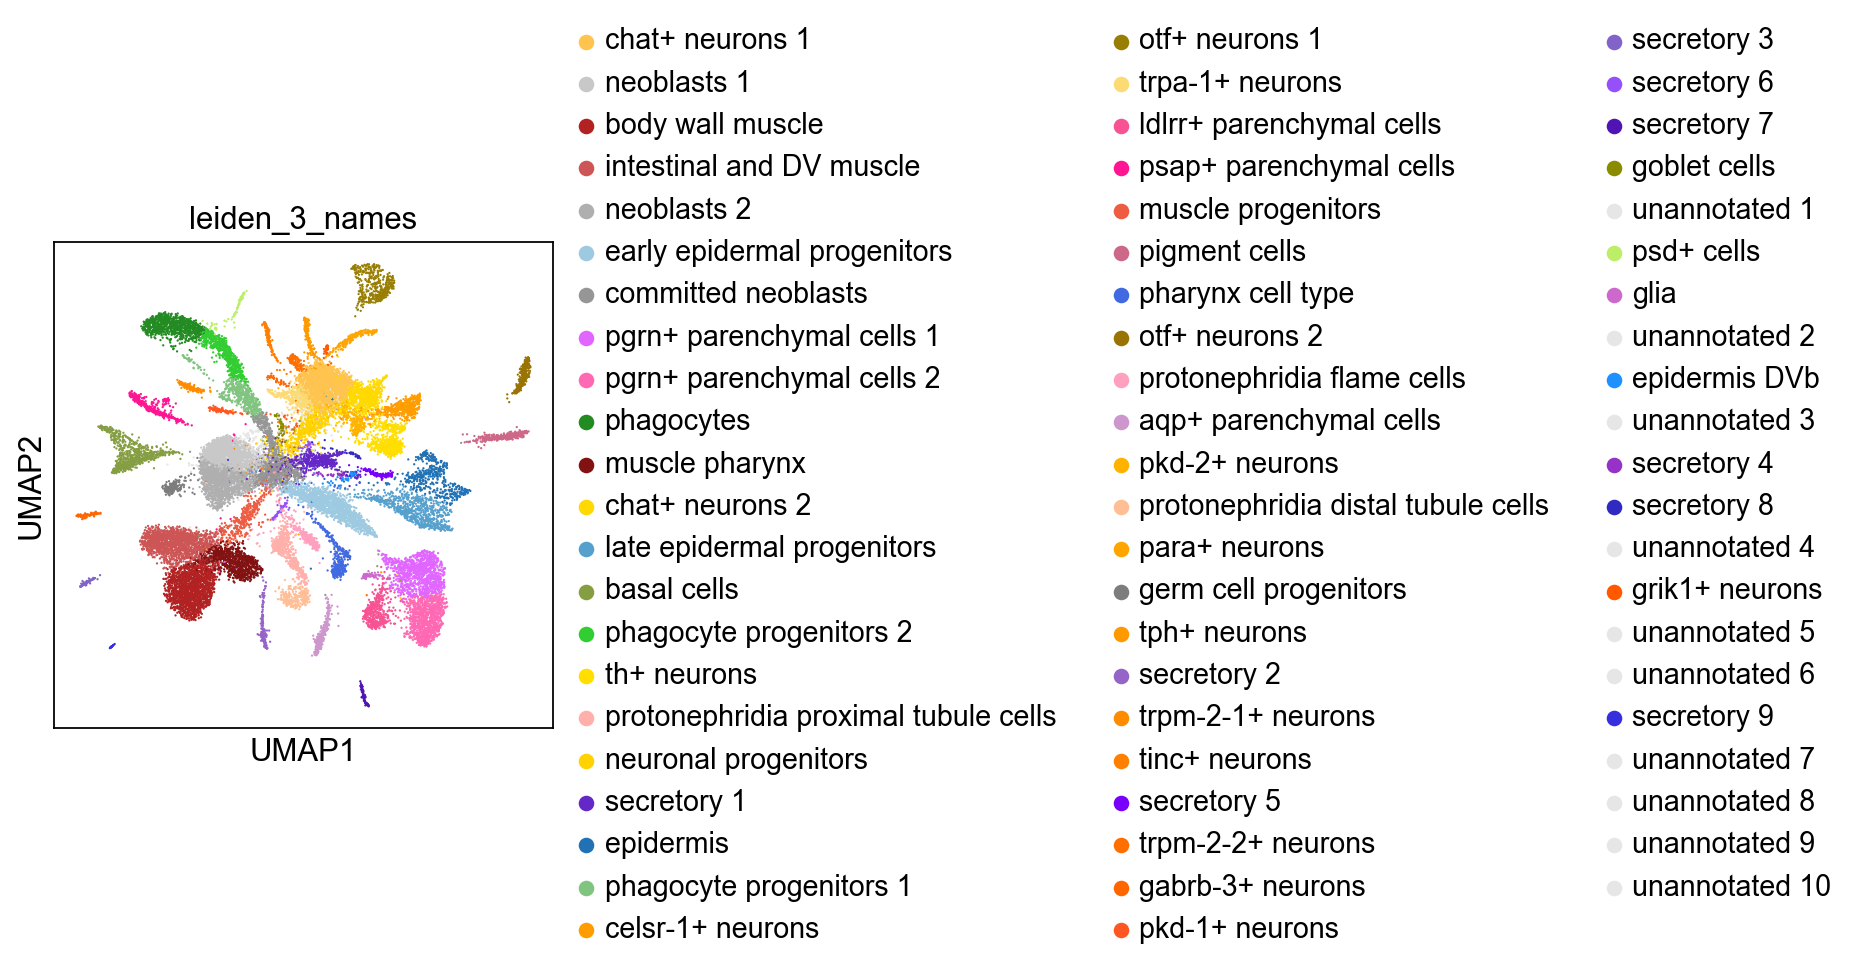

In [9]:
sc.pl.umap(adata_ref, color='leiden_3_names')

Number of clusters in the references dataframe:

In [10]:
len(adata_ref.obs['leiden_3_names'].cat.categories)

65

Reading the working experiment:

In [11]:
adata = sc.read_h5ad('./Serotonergic_data_preprocessed.h5ad')

Creating a copy of adata: We will work on the copy so we don´t modify the original object.

In [12]:
adata_ingest = adata
adata_ingest

AnnData object with n_obs × n_vars = 47292 × 24000
    obs: 'sample', 'biological_rep', 'technical_rep', 'library', 'sample_bio', 'unique', 'sample_rep', 'unique_rep', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4'
    var: 'gene_ids', 'feature_types', 'longest_isoform', 'gene_type', 'gene_JakkeGuo', 'gene_Jakke_ver1', 'gene_ddv6', 'jakkeguo_collapsed', 'jakke_ver1_collapsed', 'ddv6_collapsed', 'Preferred_name', 'Description', 'PFAMs', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'biological_replicates', 'dendrogram_leiden_1', 'dendrogram_leiden_2', 'dendrogram_leiden_3', 'dendrogram_leiden_4', 'hvg', 'leiden', 'leiden_1_colors', 'leiden_2_colors', 'leiden_3_colors', 'leiden_4_colors', 'library_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups_logreg_leiden_1', '

In [13]:
adata_ingest.var

,gene_ids,feature_types,longest_isoform,gene_type,gene_JakkeGuo,gene_Jakke_ver1,gene_ddv6,jakkeguo_collapsed,jakke_ver1_collapsed,ddv6_collapsed,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
h1SMcG0000008,h1SMcG0000008,Gene Expression,h1SMcT0000008.1,hconf,SMEST029651001.1,SMEST029651001.1,dd_Smed_v6_35379_0_1,"SMEST029651001.1,SMEST029651002.1,SmMSTRG.9911...","SMEST029651001.1,SMEST029651002.1",dd_Smed_v6_35379_0_1,...,10,0.000232,99.978886,11.0,True,0.000284,0.477953,1.455614,0.000172,0.012502
h1SMcG0000009,h1SMcG0000009,Gene Expression,h1SMcT0000009.2,hconf,SMEST029652002.1,SMEST029652002.1,dd_Smed_v6_5323_0_1,"SMEST029652002.1,SmMSTRG.9914.2,SmMSTRG.9914.3...",SMEST029652002.1,dd_Smed_v6_5323_0_1,...,196,0.004159,99.586175,197.0,True,0.003342,0.036366,0.147434,0.002345,0.039136
h1SMcG0000011,h1SMcG0000011,Gene Expression,h1SMcT0000011.1,hconf,SMEST029655001.1,SMEST029655001.1,dd_Smed_v6_6416_0_1,"SMEST029655001.1,SMEST029655002.1,SmMSTRG.9916...","SMEST029655001.1,SMEST029655002.1",dd_Smed_v6_6416_0_1,...,2366,0.053312,95.004539,2525.0,True,0.044958,0.140558,0.456098,0.031060,0.146029
h1SMcG0000012,h1SMcG0000012,Gene Expression,h1SMcT0000012.1,hconf,SmMSTRG.9913.2,SMEST029666001.1,dd_Smed_v6_20296_0_1,"SMEST029666001.1,SmMSTRG.9913.2",SMEST029666001.1,dd_Smed_v6_20296_0_1,...,25,0.000549,99.947216,26.0,True,0.000470,0.185634,0.589633,0.000318,0.015024
h1SMcG0000013,h1SMcG0000013,Gene Expression,h1SMcT0000013.5,hconf,SmMSTRG.9917.1,MSTRG.9917.1,dd_Smed_v6_4708_0_1,"SMEST029667004.1,SmMSTRG.9917.1,SmMSTRG.9917.2...","MSTRG.9917.1,SMEST029667004.1",dd_Smed_v6_4708_0_1,...,681,0.014885,98.562169,705.0,True,0.012562,0.100089,0.336211,0.008670,0.077038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
h1SMnG0034970,h1SMnG0034970,Gene Expression,h1SMnT0034970.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000040,0.120145,0.395626,0.000027,0.004380
h1SMnG0035064,h1SMnG0035064,Gene Expression,h1SMnT0035064.1,other,-,-,-,-,-,-,...,1,0.000021,99.997889,1.0,True,0.000026,0.225550,0.707884,0.000017,0.003735
h1SMnG0035227,h1SMnG0035227,Gene Expression,h1SMnT0035227.1,other,-,-,-,-,-,-,...,2,0.000042,99.995777,2.0,True,0.000049,0.321466,0.992030,0.000031,0.005060
h1SMnG0035258,h1SMnG0035258,Gene Expression,h1SMnT0035258.1,hconf,-,-,-,-,-,-,...,3,0.000063,99.993666,3.0,True,0.000092,0.375602,1.152403,0.000057,0.007119


In [14]:
adata_ingest.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,130,148.0,0.0,0.0,8,9,7,25
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,159,176.0,0.0,0.0,1,1,1,0
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,359,502.0,0.0,0.0,0,0,0,7
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,149,185.0,0.0,0.0,4,3,9,5
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,166,180.0,0.0,0.0,2,6,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,212,411.0,0.0,0.0,7,37,26,49
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,186,262.0,0.0,0.0,0,0,5,4
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,103,110.0,0.0,0.0,5,8,6,3
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,201,238.0,0.0,0.0,1,1,1,0


Both datasets need to be defined on the same variables:

In [15]:
var_names = adata_ref.var_names.intersection(adata_ingest.var_names)
var_names

Index(['h1SMcG0000009', 'h1SMcG0000011', 'h1SMcG0000012', 'h1SMcG0000013',
       'h1SMcG0000014', 'h1SMcG0000016', 'h1SMcG0000017', 'h1SMcG0000021',
       'h1SMcG0000023', 'h1SMcG0000025',
       ...
       'h1SMnG0033464', 'h1SMnG0033550', 'h1SMnG0033904', 'h1SMnG0034031',
       'h1SMnG0034035', 'h1SMnG0034138', 'h1SMnG0034488', 'h1SMnG0034866',
       'h1SMnG0035254', 'h1SMnG0035418'],
      dtype='object', length=16230)

In [16]:
adata_ref = adata_ref[:, var_names]
adata_ingest = adata_ingest[:, var_names]

Now 'adata_ingest' and 'adata_ref' only conserve the matching variables:

In [17]:
adata_ingest.shape

(47292, 16230)

In [18]:
adata_ref.shape

(28738, 16230)

Adata is not modified:

In [19]:
adata.shape

(47292, 24000)

**Ingest label transfer**

In [20]:
sc.tl.ingest(adata_ingest, adata_ref, obs='leiden_3_names', embedding_method=('umap', 'pca'), labeling_method='knn', neighbors_key=None, inplace=True)

running ingest
    finished (0:04:03)


In [21]:
adata_ingest.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,leiden_3_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,130,148.0,0.0,0.0,8,9,7,25,pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,159,176.0,0.0,0.0,1,1,1,0,chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,359,502.0,0.0,0.0,0,0,0,7,neoblasts 1
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,149,185.0,0.0,0.0,4,3,9,5,early epidermal progenitors
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,166,180.0,0.0,0.0,2,6,3,9,intestinal and DV muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,212,411.0,0.0,0.0,7,37,26,49,epidermis
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,186,262.0,0.0,0.0,0,0,5,4,neoblasts 1
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,103,110.0,0.0,0.0,5,8,6,3,pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,201,238.0,0.0,0.0,1,1,1,0,chat+ neurons 1


Create a new column in original 'adata' with annotation from 'leiden_names':

This is to recover the full shape adata dataframe plus new annotation column (Reminder: adata_ingest is a reduced version with less variables).

In [22]:
adata.obs['ingest_names'] = adata_ingest.obs['leiden_3_names']
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,130,148.0,0.0,0.0,8,9,7,25,pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,159,176.0,0.0,0.0,1,1,1,0,chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,359,502.0,0.0,0.0,0,0,0,7,neoblasts 1
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,149,185.0,0.0,0.0,4,3,9,5,early epidermal progenitors
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,166,180.0,0.0,0.0,2,6,3,9,intestinal and DV muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,212,411.0,0.0,0.0,7,37,26,49,epidermis
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,186,262.0,0.0,0.0,0,0,5,4,neoblasts 1
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,103,110.0,0.0,0.0,5,8,6,3,pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,201,238.0,0.0,0.0,1,1,1,0,chat+ neurons 1


In [23]:
adata_ingest.shape

(47292, 16230)

In [24]:
adata.shape

(47292, 24000)

Number of clusters transferred successfully:

In [25]:
len(adata.obs['ingest_names'].cat.categories.to_list())

65

In [26]:
len(adata.obs['leiden_3'].cat.categories.to_list())

74

**Add reference cluster colours to adata**

In [27]:
list(adata_ref.uns)

['dendrogram_leiden_1',
 'dendrogram_leiden_2',
 'dendrogram_leiden_3',
 'dendrogram_leiden_4',
 'hvg',
 'leiden',
 'leiden_1_colors',
 'leiden_2_colors',
 'leiden_3_colors',
 'leiden_3_names_colors',
 'leiden_4_colors',
 'log1p',
 'neighbors',
 'pca',
 'rank_genes_groups_logreg_leiden_1',
 'rank_genes_groups_logreg_leiden_2',
 'rank_genes_groups_logreg_leiden_3',
 'rank_genes_groups_logreg_leiden_4',
 'rank_genes_groups_wilcox_leiden_1',
 'rank_genes_groups_wilcox_leiden_2',
 'rank_genes_groups_wilcox_leiden_3',
 'rank_genes_groups_wilcox_leiden_4',
 'umap']

In [28]:
cluster_colours = adata_ref.uns['leiden_3_names_colors']
cluster_colours

array(['#fec44f', '#c8c8c8', '#b22222', '#cd5555', '#afafaf', '#9ecae1',
       '#969696', '#e066ff', '#ff69b4', '#228b22', '#821111', '#ffd900',
       '#56a0ce', '#869e42', '#32cd32', '#ffde00', '#ffb0ab', '#ffd200',
       '#6428c8', '#2171b5', '#80c480', '#ff9d00', '#997e04', '#fcdb74',
       '#f75394', '#ff1493', '#ee5c42', '#cd6889', '#4169e1', '#997404',
       '#ffa0be', '#cd96cd', '#ffb300', '#ffbe96', '#ffa500', '#7d7d7d',
       '#ff9900', '#9664c8', '#ff8c00', '#ff7f00', '#7800fa', '#ff6f00',
       '#ff6600', '#ff5722', '#8264c8', '#9650fa', '#5014b4', '#8b8b00',
       '#e6e6e6', '#bcee68', '#cd69cd', '#e6e6e6', '#1e90ff', '#e6e6e6',
       '#9632c8', '#3029c2', '#e6e6e6', '#ff5900', '#e6e6e6', '#e6e6e6',
       '#372fde', '#e6e6e6', '#e6e6e6', '#e6e6e6', '#e6e6e6'],
      dtype=object)

In [29]:
adata.uns['ingest_names_colors']=cluster_colours

**Plot transfered clusters**

*Clusters changes slighly compared with the original clustering

C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


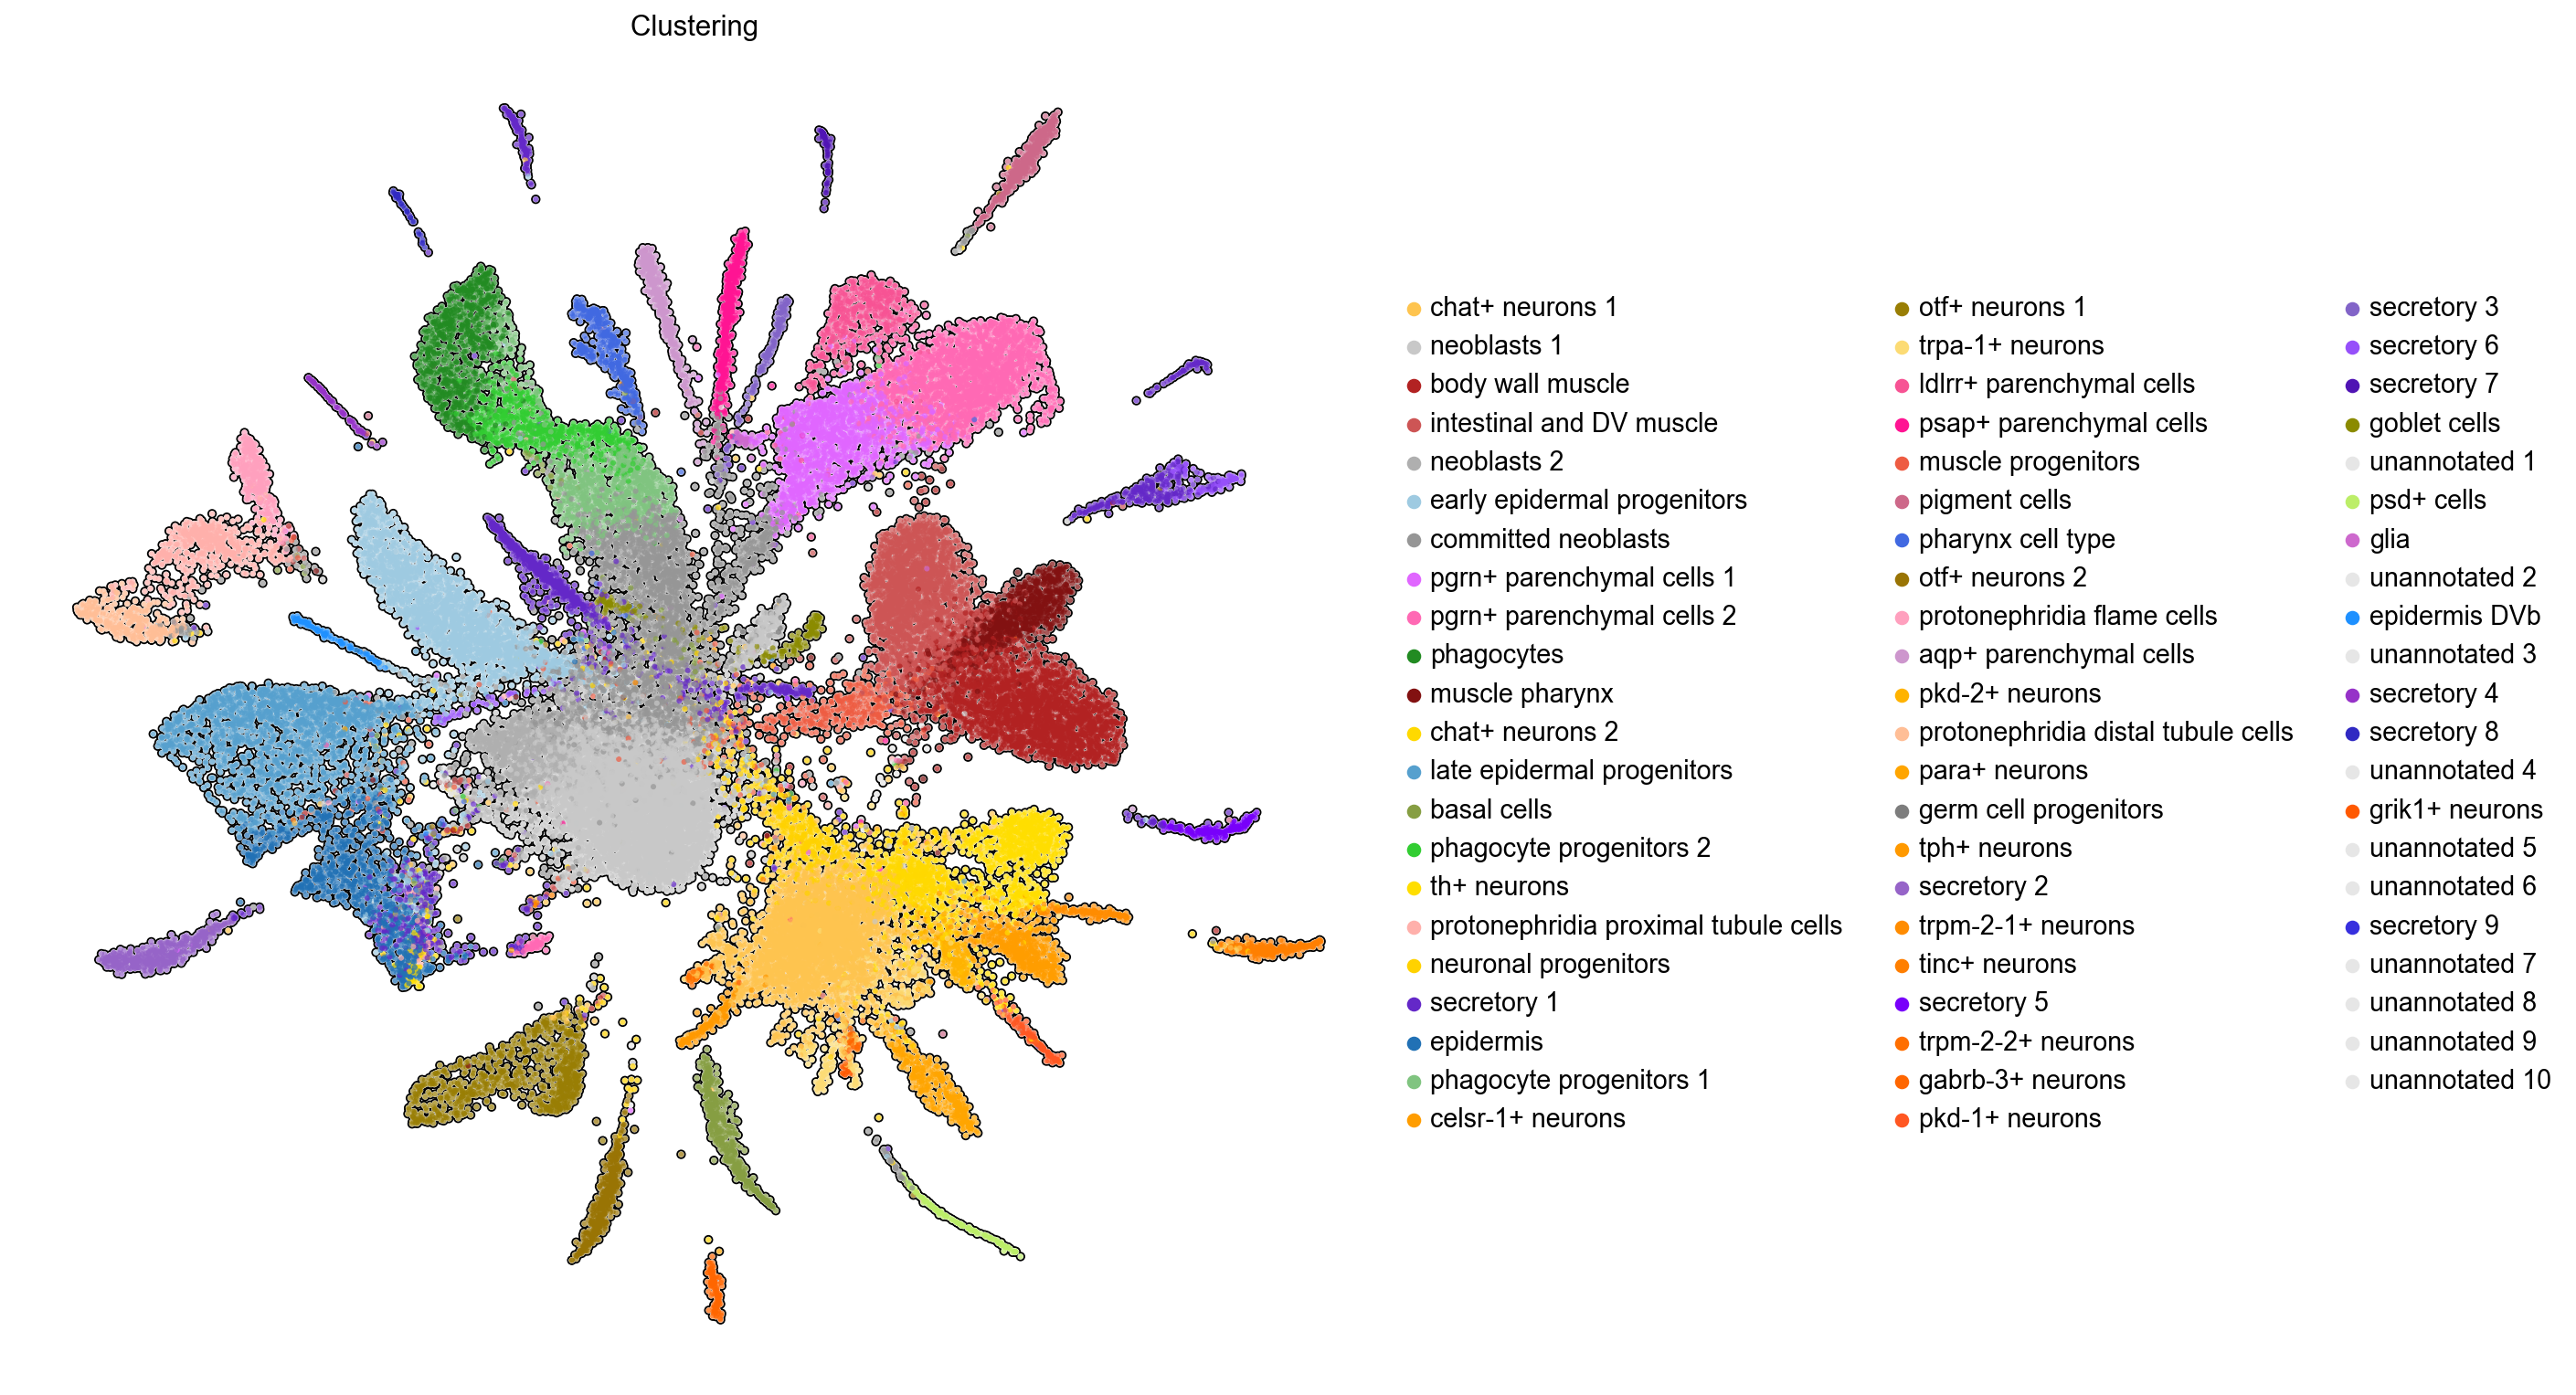

In [30]:
with rc_context({'figure.figsize': (12, 12)}):
     sc.pl.umap(adata, color=['ingest_names'], legend_fontoutline = 5, title= 'Clustering ', size = 30, 
         frameon=False, add_outline = True)

C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


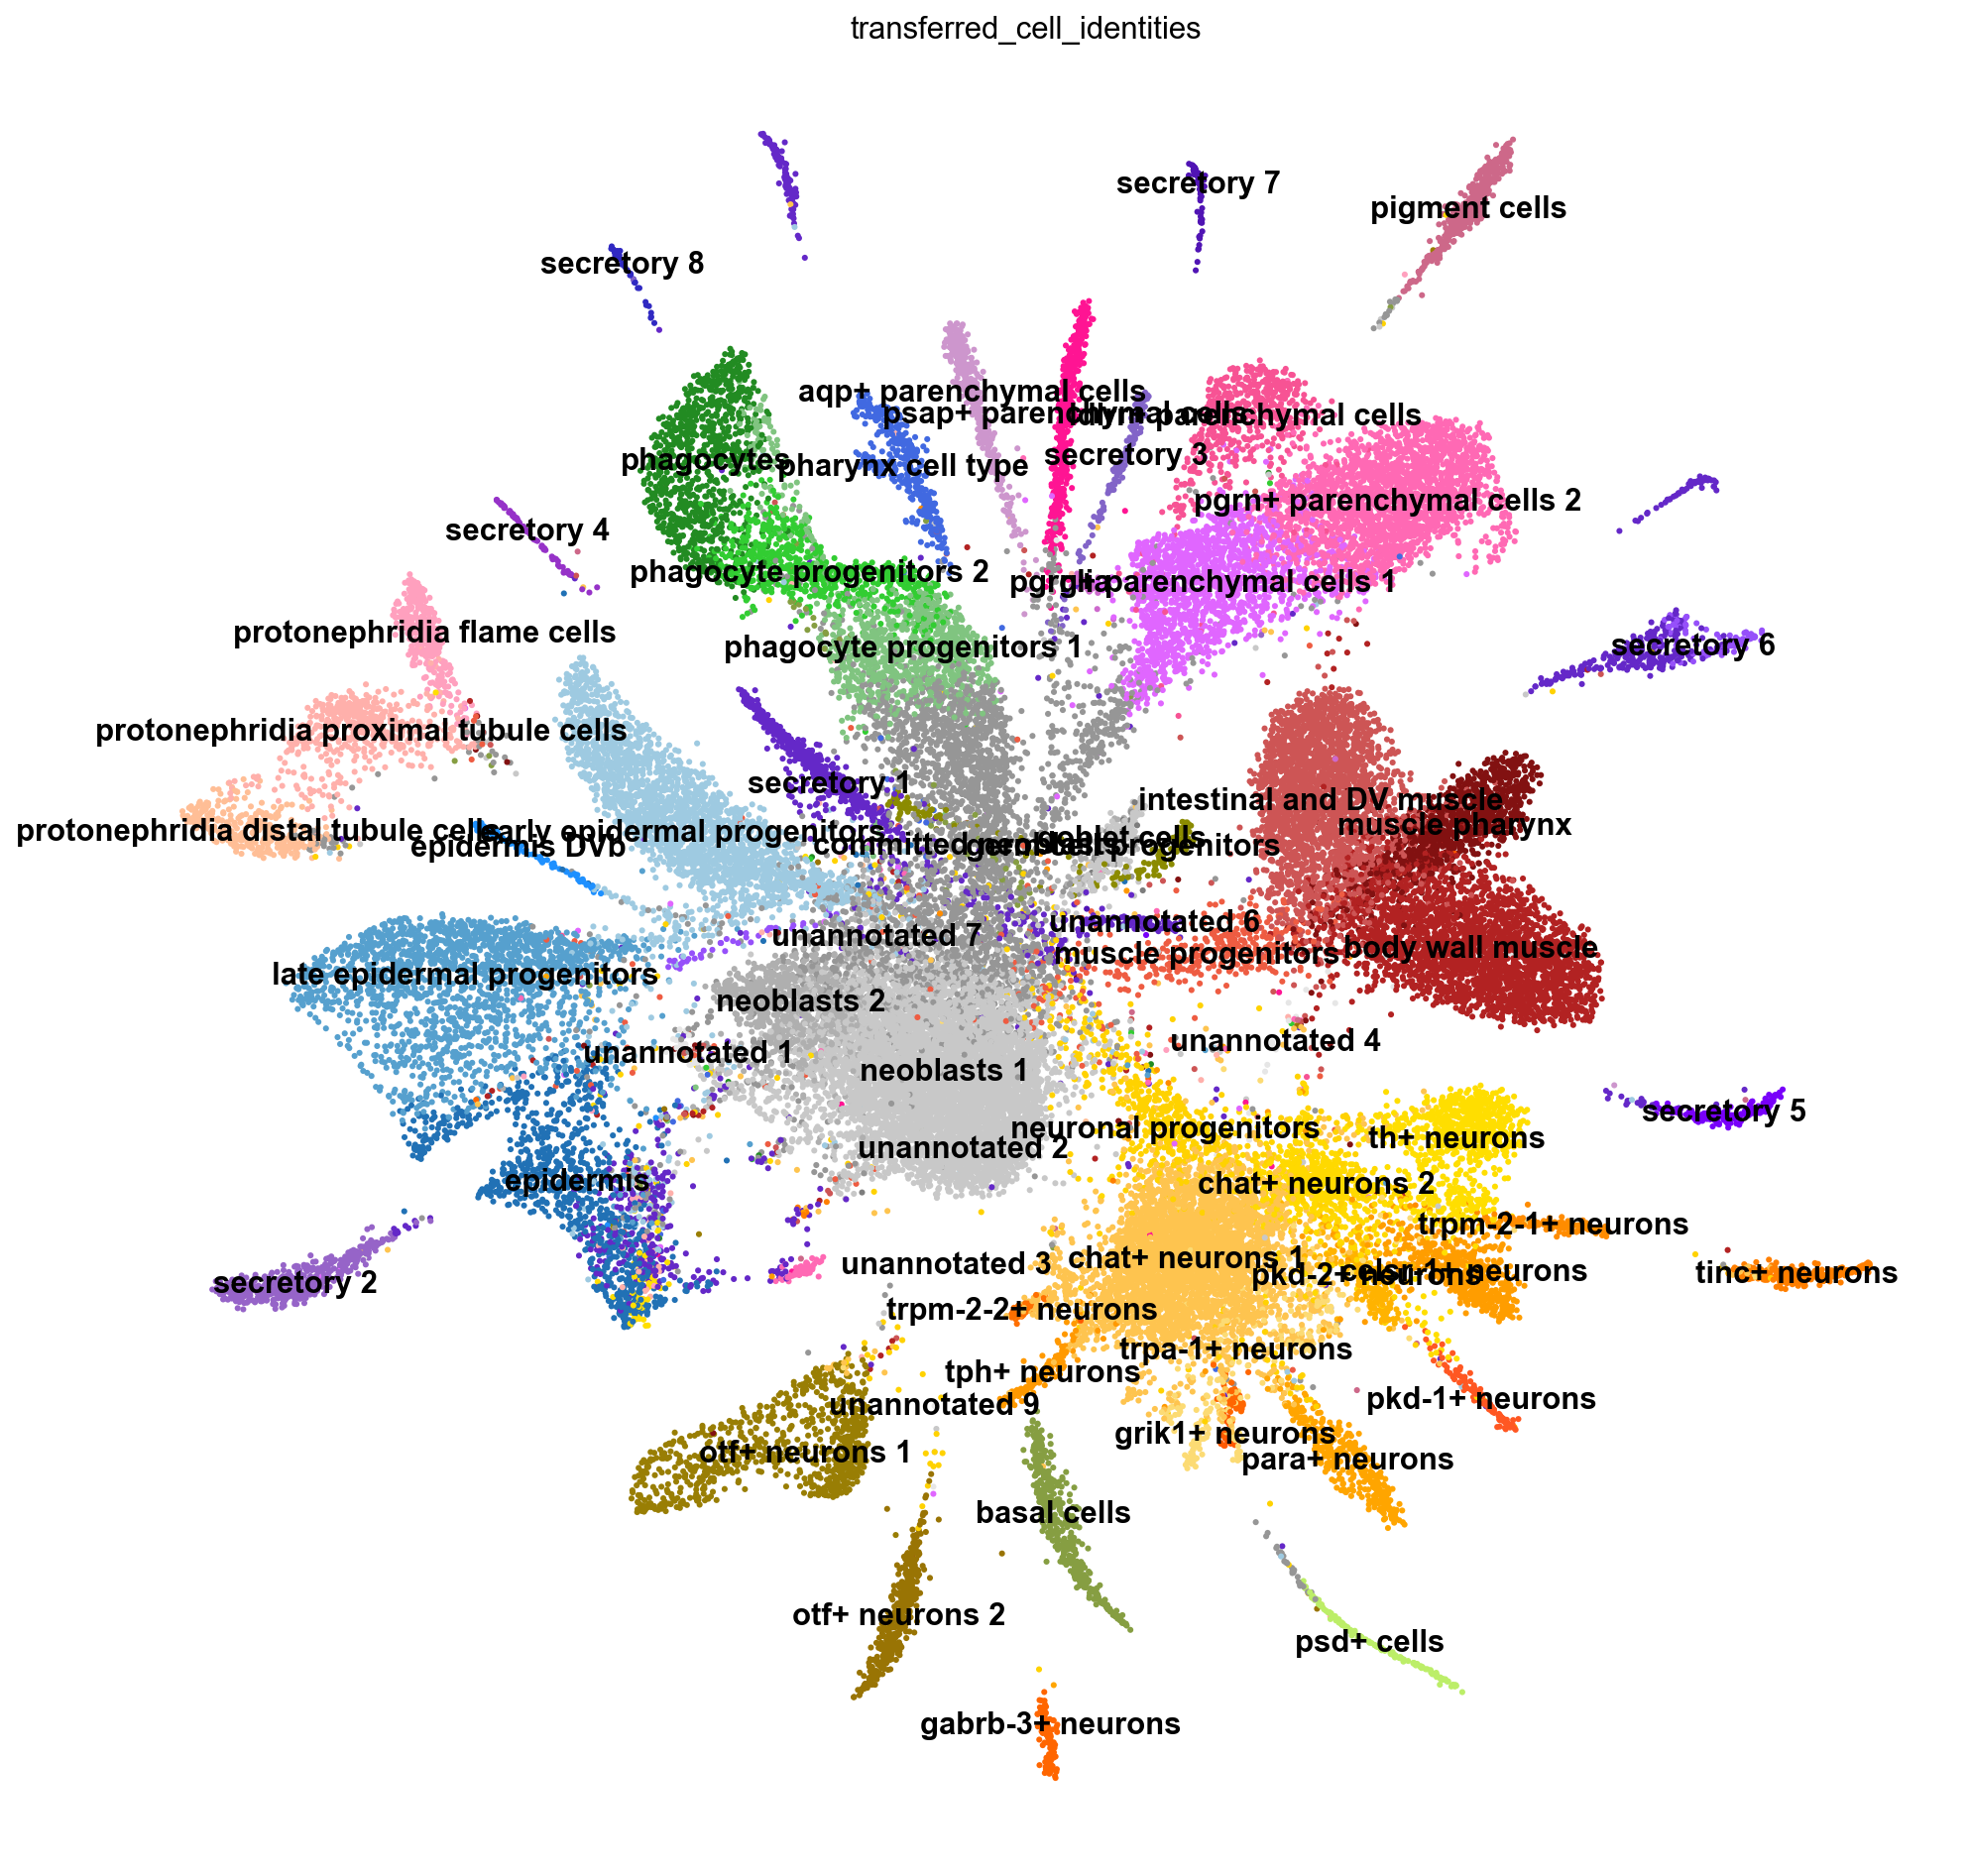

In [31]:
with rc_context({'figure.figsize': (15, 15)}):
    sc.pl.umap(adata, color=['ingest_names'], legend_loc='on data', title='transferred_cell_identities', size = 30, frameon=False)

# Transfer labels to one of our clustering resolutions

New column 'transferred' matching clusters from 'leiden_3' column and identites from 'cluster_names' column:

In [32]:
for i in adata.obs['leiden_3'].cat.categories:
    filt = adata.obs['leiden_3'] == i
    adata.obs.loc[filt,'transferred']=adata.obs[filt]['ingest_names'].value_counts().sort_index().idxmax()

In [33]:
adata.obs

,sample,biological_rep,technical_rep,library,sample_bio,unique,sample_rep,unique_rep,n_counts,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden_1,leiden_2,leiden_3,leiden_4,ingest_names,transferred
L43_1_AACCATTGGAGACTAGTAACGCTCGA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,148.0,130,130,148.0,0.0,0.0,8,9,7,25,pgrn+ parenchymal cells 1,pgrn+ parenchymal cells 1
L43_1_CATTCGACGGAGATCGCACGCTGATC,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,176.0,159,159,176.0,0.0,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1
L43_1_ACGGAGGCGGTGGAACAATAGGATGA,gfp(RNAi),B2,T1,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib1,502.0,359,359,502.0,0.0,0.0,0,0,0,7,neoblasts 1,neoblasts 1
L43_1_GACCTTGATAACGCTCGACAAGACTA,gfp(RNAi),B2,T2,Lib1,gfp(RNAi)_B2,gfp(RNAi)_Lib1,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib1,185.0,149,149,185.0,0.0,0.0,4,3,9,5,early epidermal progenitors,early epidermal progenitors
L43_1_TTACCTCGACTGGAACAAAGATCGCA,lhx1/5-1(RNAi),B1,T2,Lib1,lhx1/5-1(RNAi)_B1,lhx1/5-1(RNAi)_Lib1,lhx1/5-1(RNAi)_B1_T2,lhx1/5-1(RNAi)_B1_T2_Lib1,180.0,166,166,180.0,0.0,0.0,2,6,3,9,intestinal and DV muscle,intestinal and DV muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L43_5_TAACTGGTTAAAGGTACAGAGTTAGC,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,411.0,212,212,411.0,0.0,0.0,7,37,26,49,epidermis,epidermis
L43_5_GGTACCGGCAGAATCTGATGAAGAGA,gfp(RNAi),B2,T2,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T2,gfp(RNAi)_B2_T2_Lib5,262.0,186,186,262.0,0.0,0.0,0,0,5,4,neoblasts 1,neoblasts 1
L43_5_GCCGCAACGACCAGTTCAAGCAGGAA,gfp(RNAi),B1,T2,Lib5,gfp(RNAi)_B1,gfp(RNAi)_Lib5,gfp(RNAi)_B1_T2,gfp(RNAi)_B1_T2_Lib5,110.0,103,103,110.0,0.0,0.0,5,8,6,3,pgrn+ parenchymal cells 2,pgrn+ parenchymal cells 2
L43_5_CCAGTTCCAATGGAACAAATTGGCTC,gfp(RNAi),B2,T1,Lib5,gfp(RNAi)_B2,gfp(RNAi)_Lib5,gfp(RNAi)_B2_T1,gfp(RNAi)_B2_T1_Lib5,238.0,201,201,238.0,0.0,0.0,1,1,1,0,chat+ neurons 1,chat+ neurons 1


Colours don't match and we get less cluster identities: 

In [34]:
len(adata.obs['transferred'].astype('category').cat.categories.to_list())

47

In [35]:
len(adata.obs['leiden_3'].cat.categories.to_list())

74

In [36]:
pivot_df = adata.obs.pivot_table(index='leiden_3', values='transferred', aggfunc='first')

In [37]:
pivot_df 

,transferred
leiden_3,
0,neoblasts 1
1,chat+ neurons 1
2,body wall muscle
3,intestinal and DV muscle
4,committed neoblasts
...,...
69,neoblasts 1
70,neoblasts 1
71,chat+ neurons 1


In [38]:
pivot_df.to_clipboard()

C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


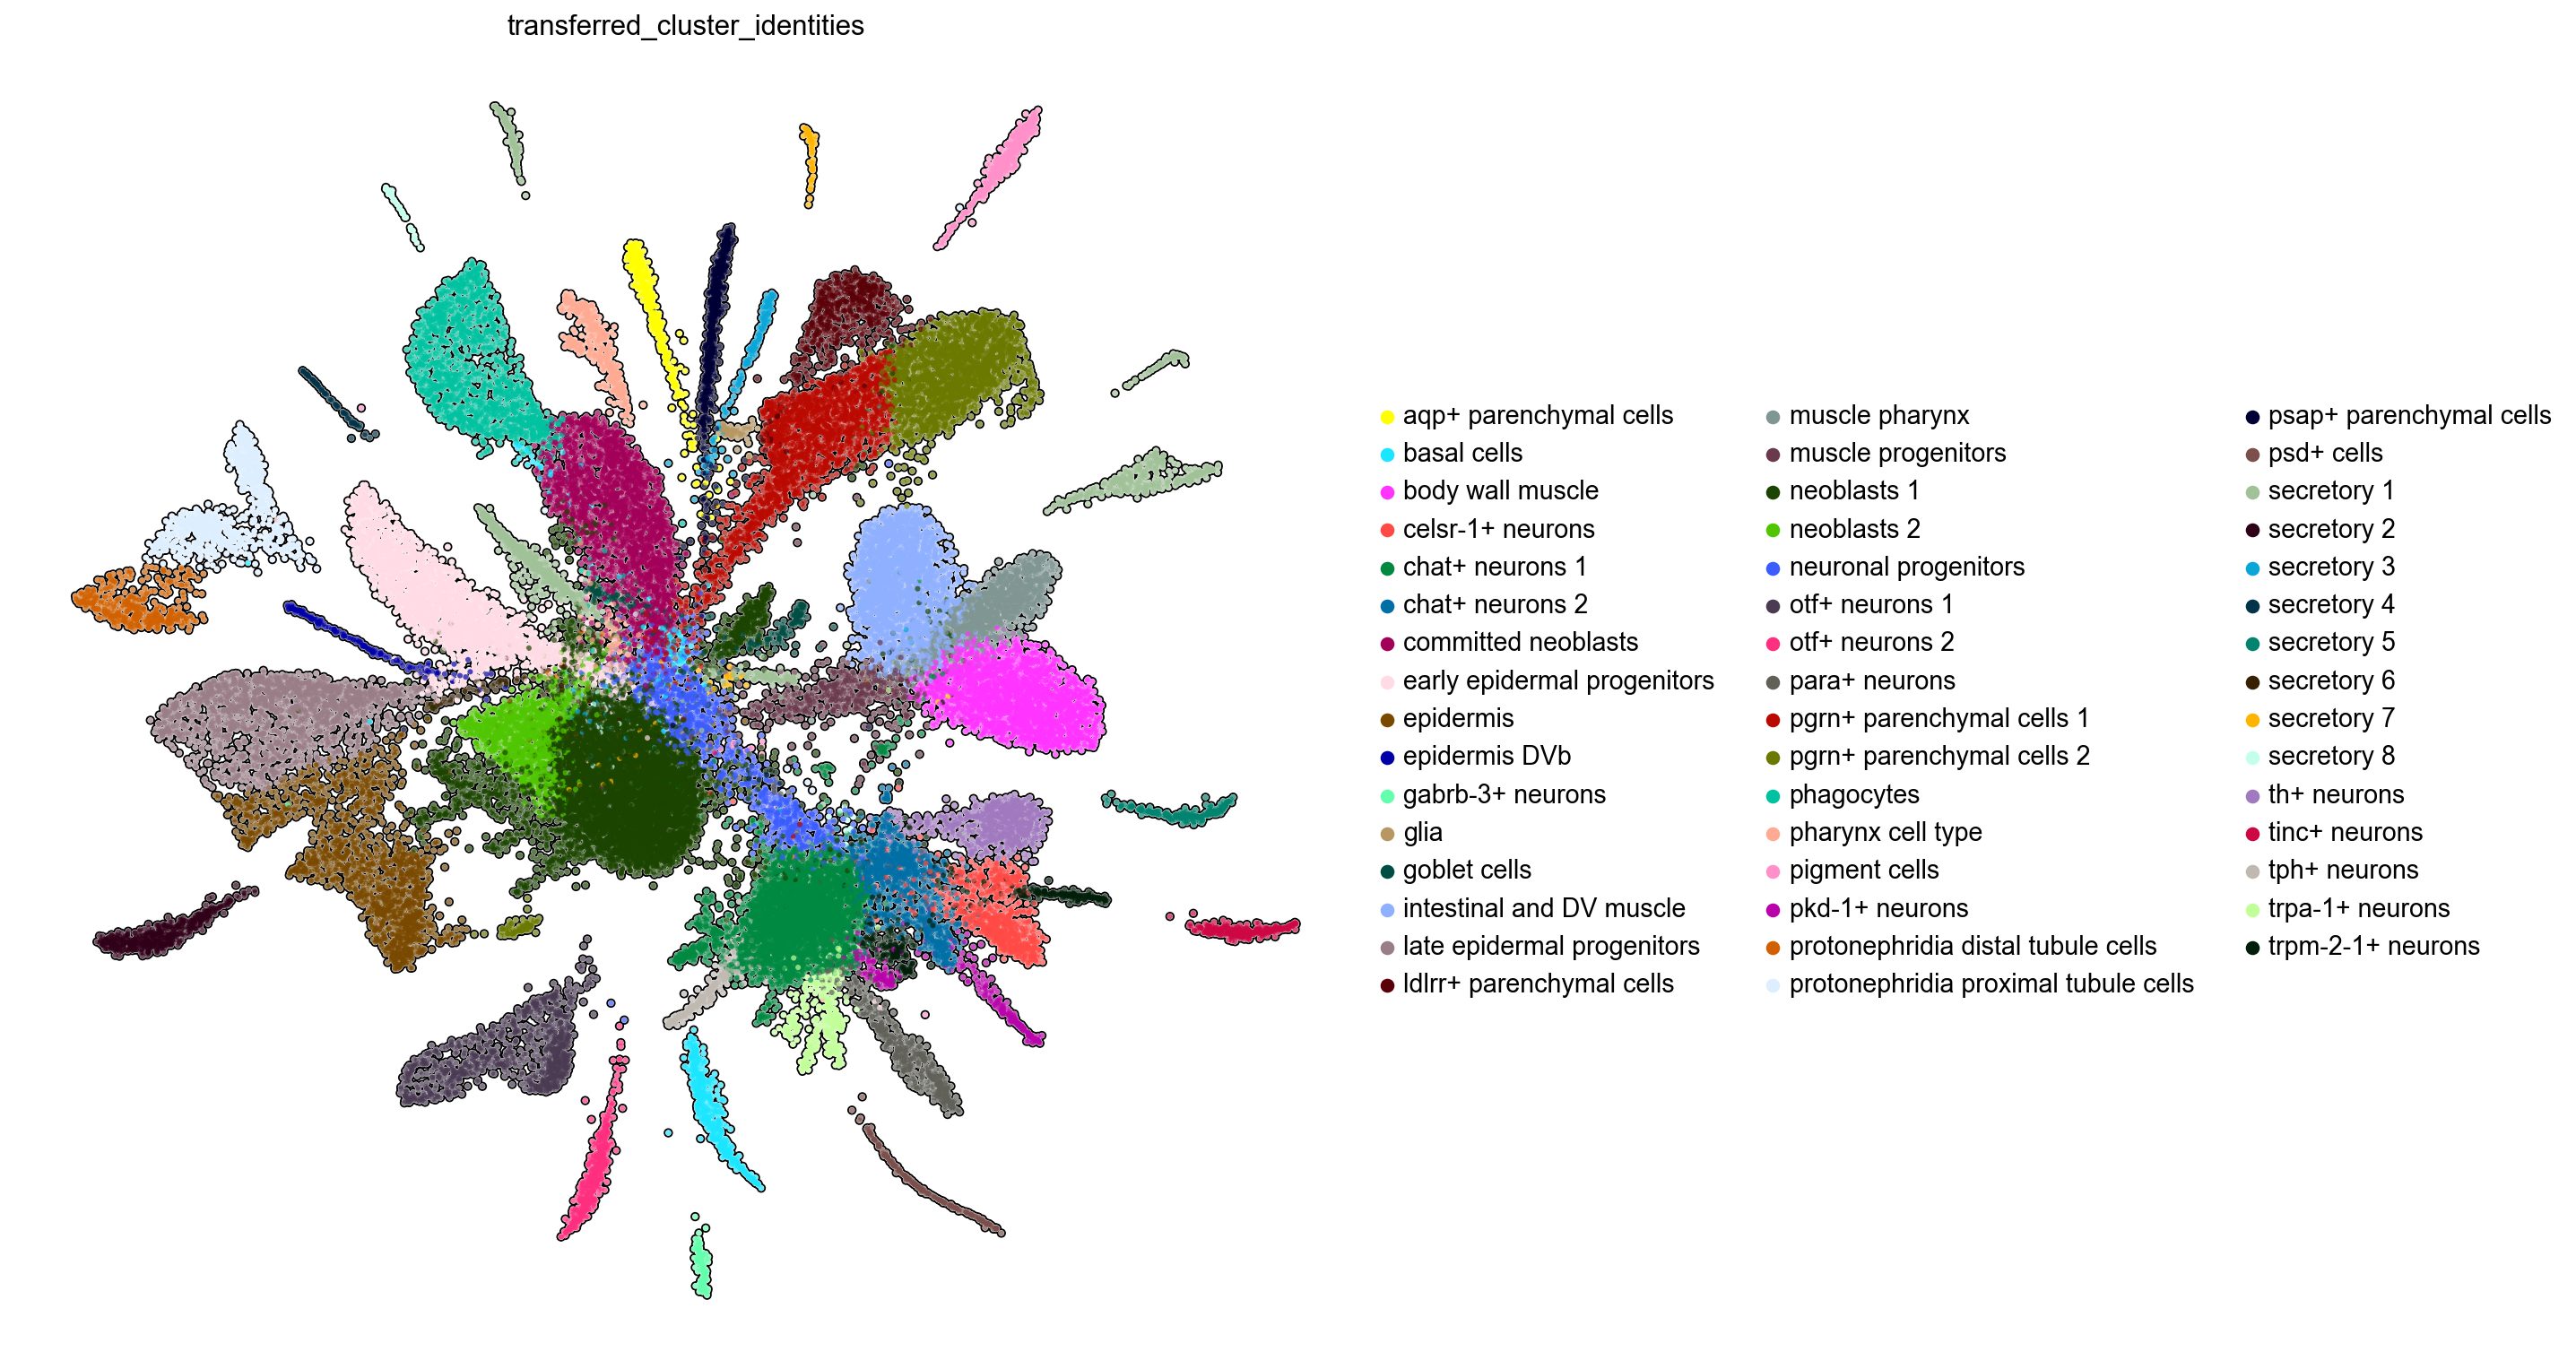

In [39]:
with rc_context({'figure.figsize': (12, 12)}):
     sc.pl.umap(adata, color=['transferred'], legend_fontoutline = 5, title= 'transferred_cluster_identities', size = 30, 
     frameon=False, add_outline = True)

C:\Users\19125778\Anaconda3\envs\PyDEseq2\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


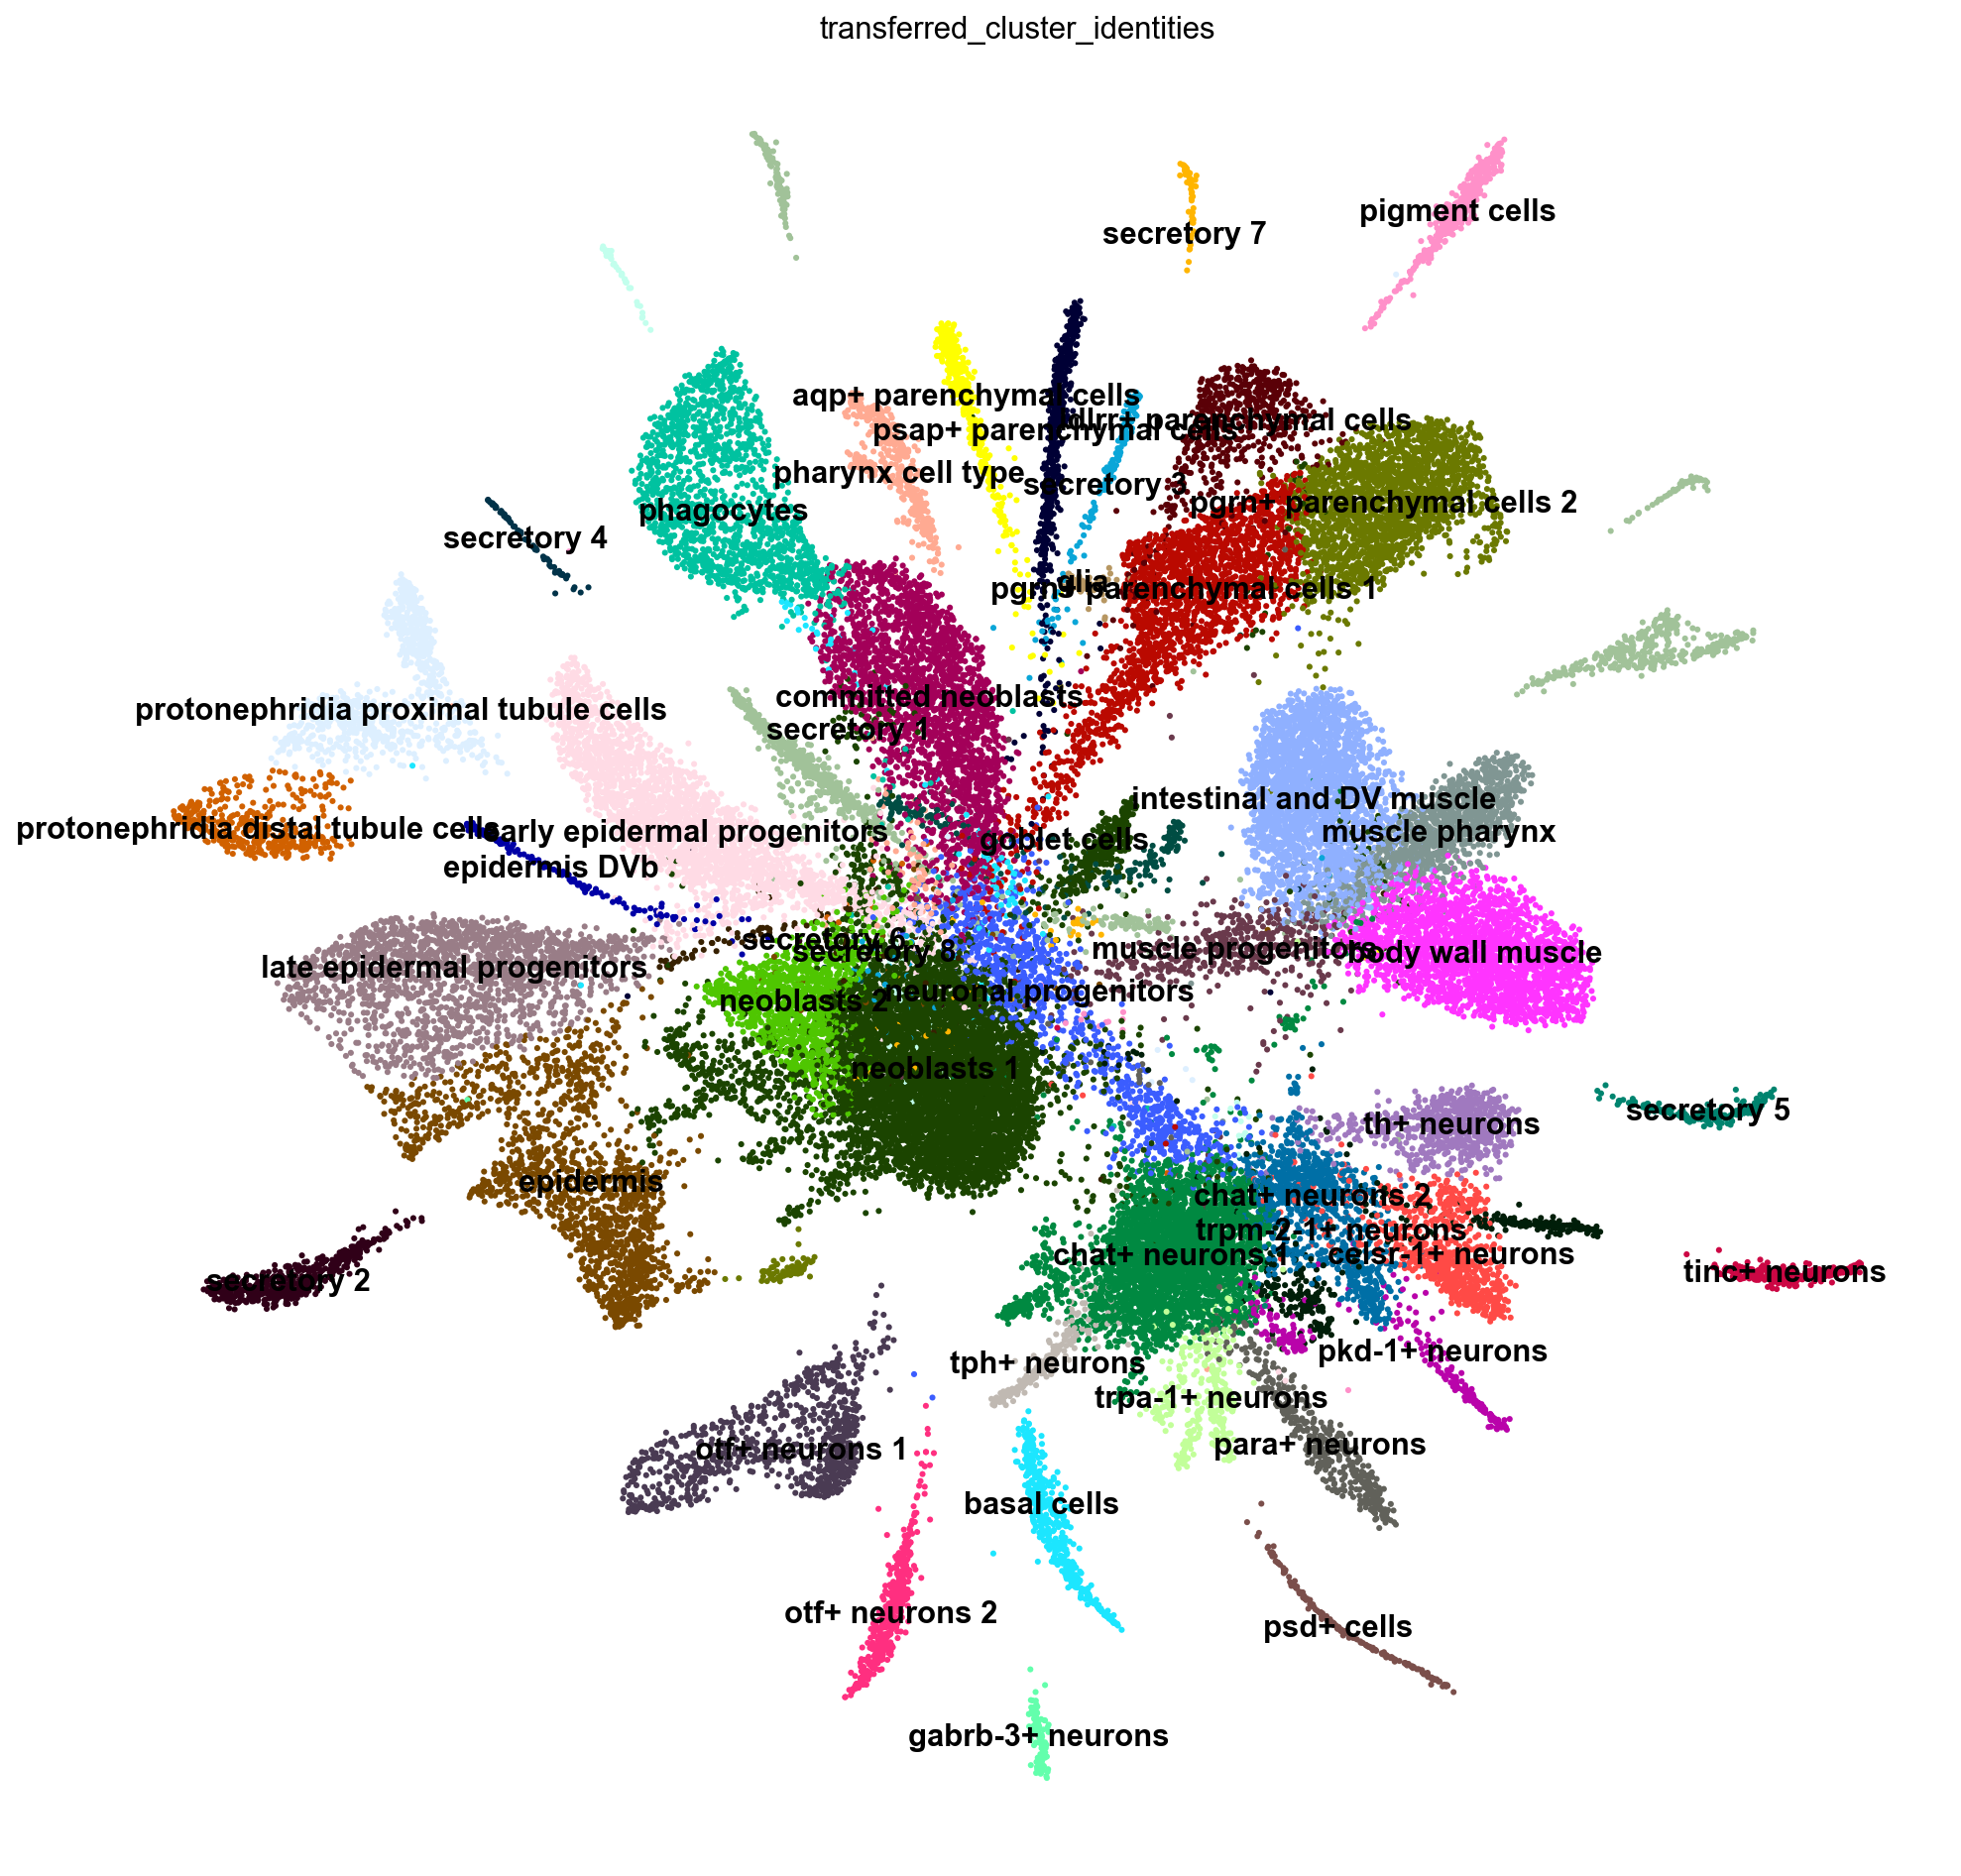

In [40]:
with rc_context({'figure.figsize': (15, 15)}):
    sc.pl.umap(adata, color=['transferred'], legend_loc='on data', title= 'transferred_cluster_identities', size = 30, frameon=False)

# Saving changes

In [41]:
adata.write(results_file)